# Connessione al db

In [554]:
import pandas as pd
import numpy as np
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

import matplotlib.pyplot as plt
import os

# Configurazione pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [555]:
conn = get_mysql_connection()

# Carica tutti i dati da raw_data in un DataFrame
query = "SELECT * FROM clean_data"
df = pd.read_sql(query, conn)

conn.close()

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
df.head()

Dataset caricato: 144 righe, 37 colonne


C:\Users\Utente\AppData\Local\Temp\ipykernel_23956\3523368477.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,4,4,4.0,4.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...
1,2,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,4,3,4.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,4,1,3,3,5,2,2,2,4,Durante gli esami
2,3,None,Lavoro,26,Maschio,Nord Italia,5.0,3,4,3,4,4,4.0,5.0,3.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,4.0,2.0,4.0,5.0,5.0,3,5,1,1,4,2,5,4,5,Interazione con persone (clienti)
3,4,None,Entrambi,26,Femmina,Nord Italia,5.0,2,4,3,5,5,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,5.0,3.0,5.0,3.0,2,5,3,3,2,3,2,1,3,L’esame
4,5,None,Studio,22,Femmina,Nord Italia,2.0,3,2,3,4,4,3.0,2.0,2.0,3.0,1.0,4.0,3.0,3.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,2,2,3,2,4,3,3,2,4,"Durante il tirocinio, quando devo mettere effe..."


# Calcolo degli indici

In [556]:
df["ansia_prestazione"] = df[["Item_1", "Item_2", "Item_3", "Item_4", "Item_6", "Item_11", "Item_20", "Item_21"]].mean(axis=1)
df["ansia_accademica"] = df[["Item_7", "Item_8", "Item_9", "Item_10"]].mean(axis=1)
df["ansia_lavorativa"] = df[["Item_12", "Item_13", "Item_14", "Item_15"]].mean(axis=1)
df["perfezionismo"] = df[["Item_16", "Item_17", "Item_18", "Item_19"]].mean(axis=1)
df["impatto_ansia"] = df[["Item_5", "Item_22", "Item_27", "Item_28", "Item_29"]].mean(axis=1)
df["coping"] = df[["Item_23", "Item_24", "Item_25", "Item_26"]].mean(axis=1)

In [557]:
# ansia totale
df['ansia'] = df[["ansia_prestazione", "ansia_accademica", "ansia_lavorativa"]].mean(axis=1)

In [558]:
# fragilità/esposizione allo stress
df["vulnerabilita"] = (df["perfezionismo"] + df["ansia"]) / 2

# capacità di fronteggiare l'ansia
df["resilienza"] = (df["coping"] - df["ansia"])

# gap percezione-prestazione (quanto l’ansia distorce la performance )
df["gap"] = (df["Item_8"] - df["coping"])

# evitamento delle situazioni che mettono ansia
df["evitamento"] = df[["Item_10", "Item_15", "Item_27", "Item_28"]].mean(axis=1)

# intensità dei sintomi
df["intensita_sintomatica"] = df [["Item_20", "Item_21", "Item_22"]].mean(axis=1)

In [559]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     144 non-null    int64  
 1   email                  12 non-null     object 
 2   contesto               144 non-null    object 
 3   età                    144 non-null    int64  
 4   genere                 144 non-null    object 
 5   area_geo               144 non-null    object 
 6   anni_esperienza        144 non-null    float64
 7   Item_1                 144 non-null    int64  
 8   Item_2                 144 non-null    int64  
 9   Item_3                 144 non-null    int64  
 10  Item_4                 144 non-null    int64  
 11  Item_5                 144 non-null    int64  
 12  Item_6                 141 non-null    float64
 13  Item_7                 141 non-null    float64
 14  Item_8                 141 non-null    float64
 15  Item_9

# Distribuzioni

(array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5]),
 [Text(0.5, 0, '0.5'),
  Text(1.0, 0, '1.0'),
  Text(1.5, 0, '1.5'),
  Text(2.0, 0, '2.0'),
  Text(2.5, 0, '2.5'),
  Text(3.0, 0, '3.0'),
  Text(3.5, 0, '3.5'),
  Text(4.0, 0, '4.0'),
  Text(4.5, 0, '4.5'),
  Text(5.0, 0, '5.0'),
  Text(5.5, 0, '5.5')])

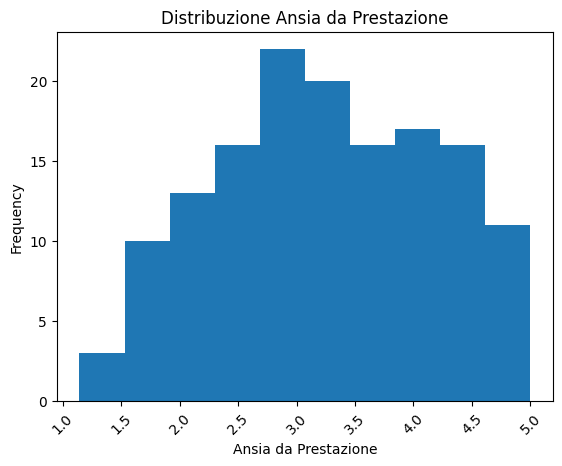

In [560]:
import matplotlib.pyplot as plt

df["ansia_prestazione"].plot(kind = 'hist')
plt.xlabel('Ansia da Prestazione')
plt.title('Distribuzione Ansia da Prestazione')
plt.xticks(rotation=45)

# Correlazioni

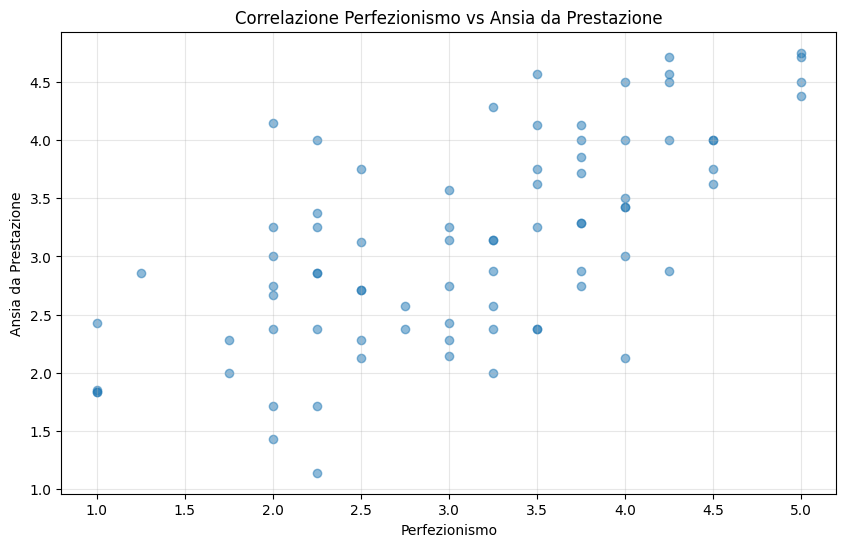

In [561]:
plt.figure(figsize=(10, 6))
plt.scatter(df["perfezionismo"], df["ansia_prestazione"], alpha=0.5)
plt.xlabel('Perfezionismo')
plt.ylabel('Ansia da Prestazione')
plt.title(f'Correlazione Perfezionismo vs Ansia da Prestazione')
plt.grid(True, alpha=0.3)

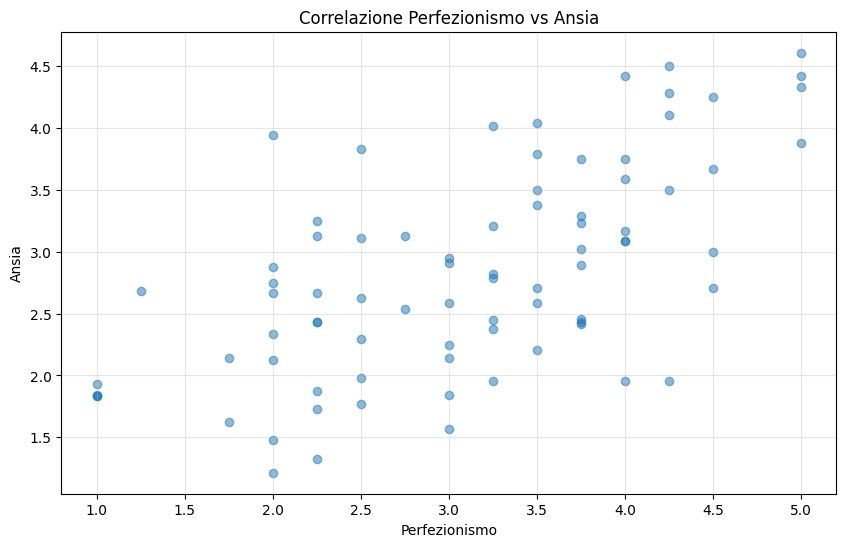

In [562]:
plt.figure(figsize=(10, 6))
plt.scatter(df["perfezionismo"], df["ansia"], alpha=0.5)
plt.xlabel('Perfezionismo')
plt.ylabel('Ansia')
plt.title(f'Correlazione Perfezionismo vs Ansia')
plt.grid(True, alpha=0.3)

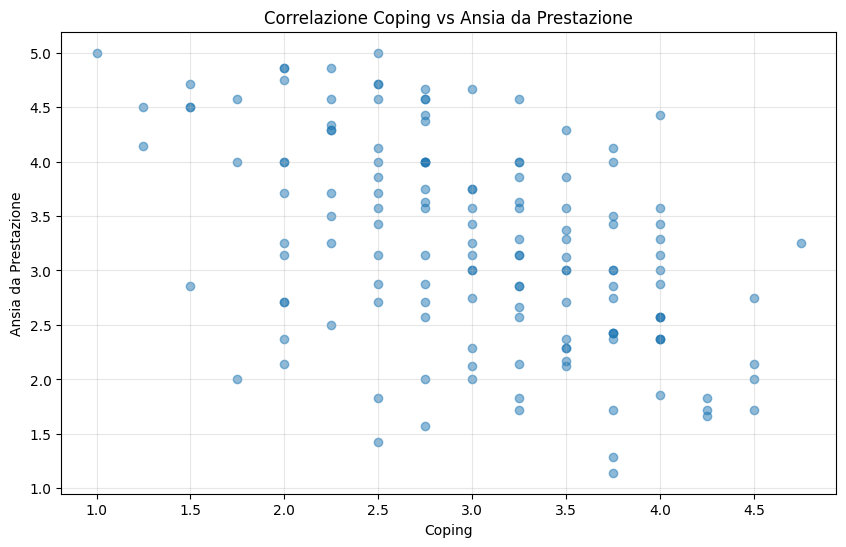

In [563]:
plt.figure(figsize=(10, 6))
plt.scatter(df["coping"], df["ansia_prestazione"], alpha=0.5)
plt.xlabel('Coping')
plt.ylabel('Ansia da Prestazione')
plt.title(f'Correlazione Coping vs Ansia da Prestazione')
plt.grid(True, alpha=0.3)

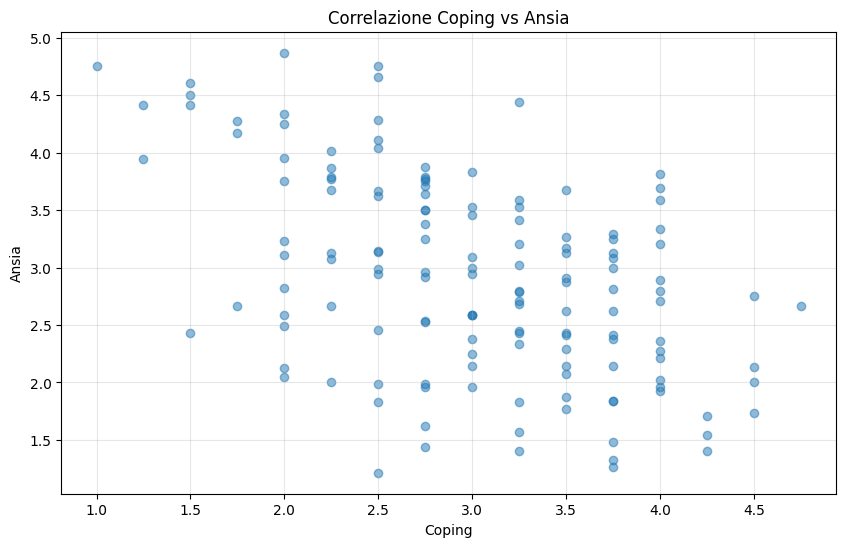

In [564]:
plt.figure(figsize=(10, 6))
plt.scatter(df["coping"], df["ansia"], alpha=0.5)
plt.xlabel('Coping')
plt.ylabel('Ansia')
plt.title(f'Correlazione Coping vs Ansia')
plt.grid(True, alpha=0.3)

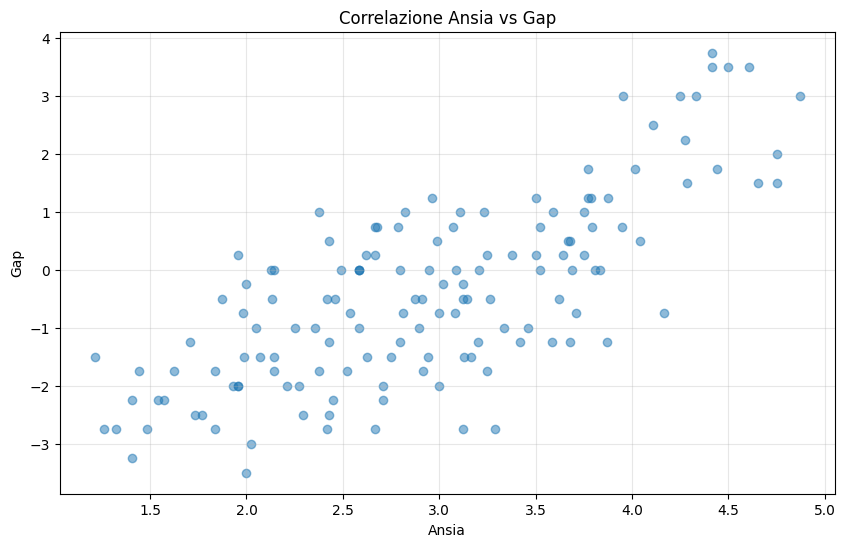

In [565]:
plt.figure(figsize=(10, 6))
plt.scatter(df["ansia"], df["gap"], alpha=0.5)
plt.xlabel('Ansia')
plt.ylabel('Gap')
plt.title(f'Correlazione Ansia vs Gap')
plt.grid(True, alpha=0.3)

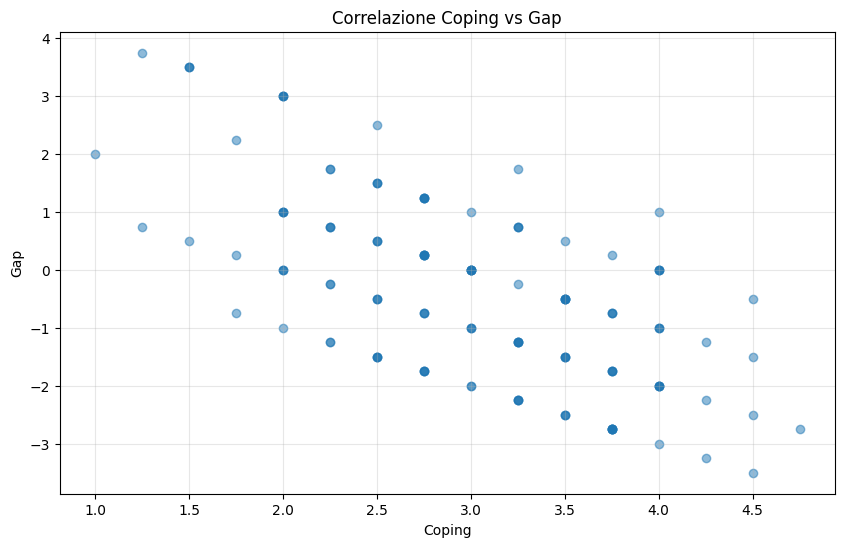

In [566]:
plt.figure(figsize=(10, 6))
plt.scatter(df["coping"], df["gap"], alpha=0.5)
plt.xlabel('Coping')
plt.ylabel('Gap')
plt.title(f'Correlazione Coping vs Gap')
plt.grid(True, alpha=0.3)

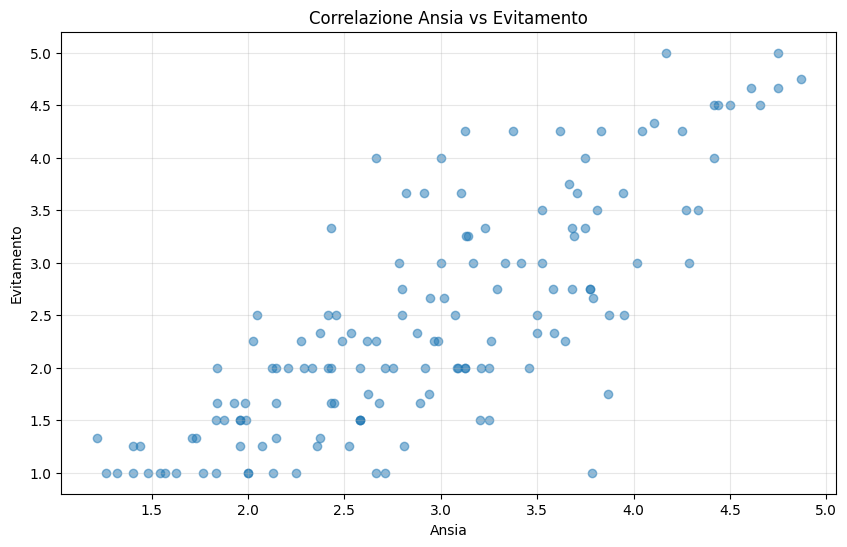

In [567]:
plt.figure(figsize=(10, 6))
plt.scatter(df["ansia"], df["evitamento"], alpha=0.5)
plt.xlabel('Ansia')
plt.ylabel('Evitamento')
plt.title(f'Correlazione Ansia vs Evitamento')
plt.grid(True, alpha=0.3)

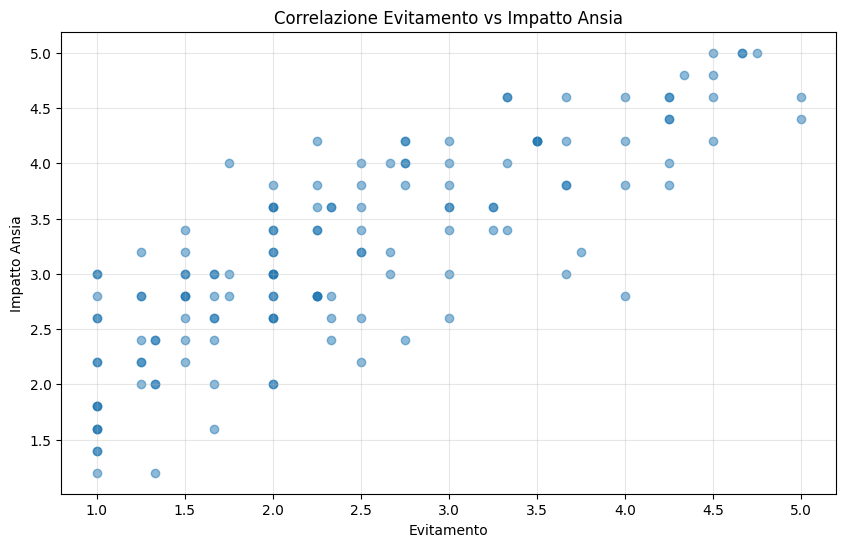

In [568]:
plt.figure(figsize=(10, 6))
plt.scatter(df["evitamento"], df["impatto_ansia"], alpha=0.5)
plt.xlabel('Evitamento')
plt.ylabel('Impatto Ansia')
plt.title(f'Correlazione Evitamento vs Impatto Ansia')
plt.grid(True, alpha=0.3)

# Correlazioni avanzate

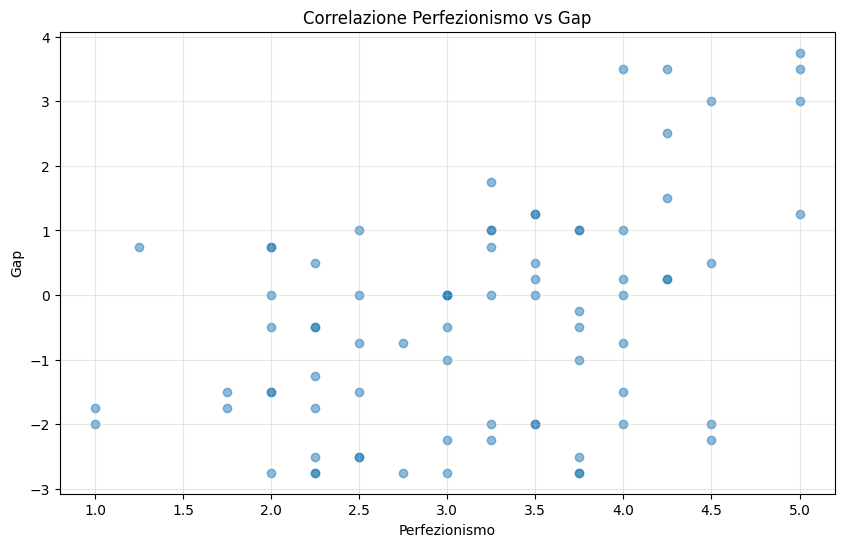

In [569]:
plt.figure(figsize=(10, 6))
plt.scatter(df["perfezionismo"], df["gap"], alpha=0.5)
plt.xlabel('Perfezionismo')
plt.ylabel('Gap')
plt.title(f'Correlazione Perfezionismo vs Gap')
plt.grid(True, alpha=0.3)

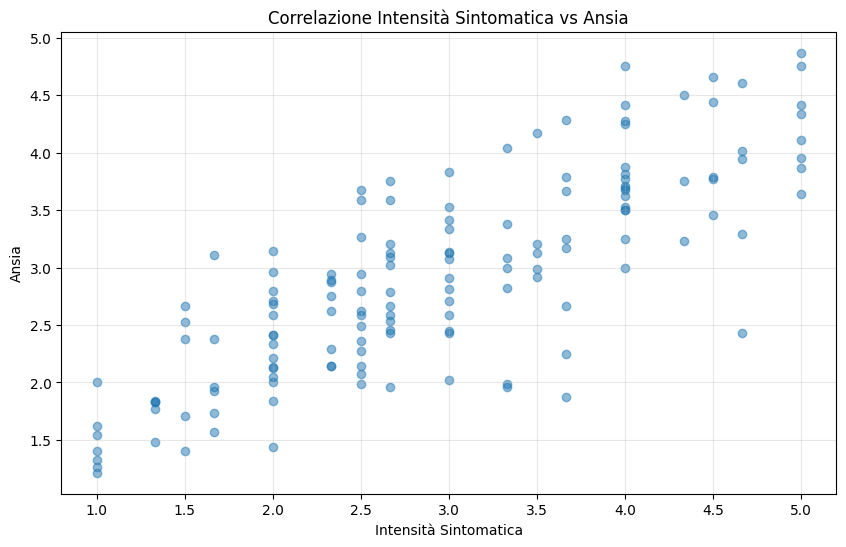

In [570]:
plt.figure(figsize=(10, 6))
plt.scatter(df["intensita_sintomatica"], df["ansia"], alpha=0.5)
plt.xlabel('Intensità Sintomatica')
plt.ylabel('Ansia')
plt.title(f'Correlazione Intensità Sintomatica vs Ansia')
plt.grid(True, alpha=0.3)

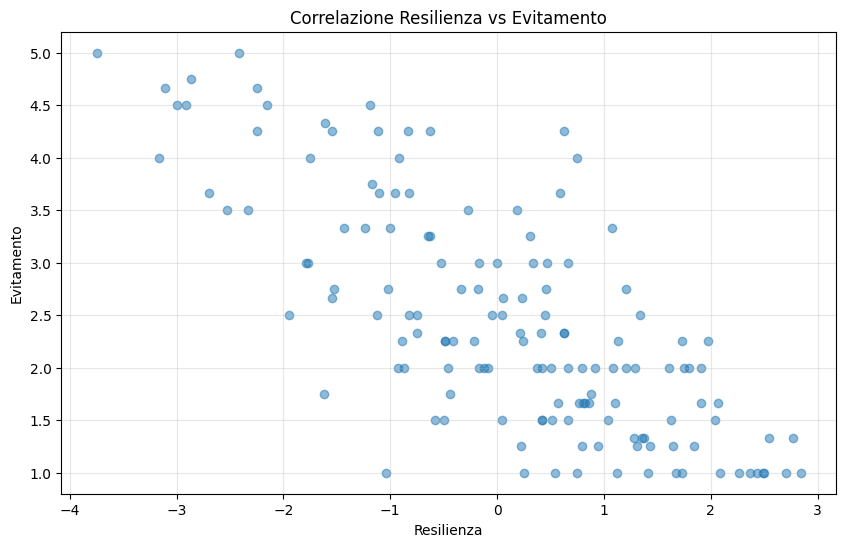

In [571]:
plt.figure(figsize=(10, 6))
plt.scatter(df["resilienza"], df["evitamento"], alpha=0.5)
plt.xlabel('Resilienza')
plt.ylabel('Evitamento')
plt.title(f'Correlazione Resilienza vs Evitamento')
plt.grid(True, alpha=0.3)

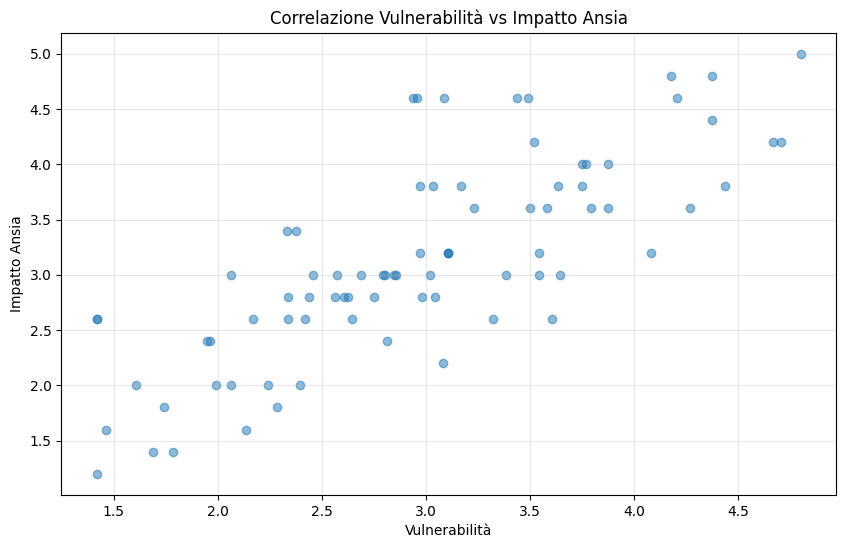

In [572]:
plt.figure(figsize=(10, 6))
plt.scatter(df["vulnerabilita"], df["impatto_ansia"], alpha=0.5)
plt.xlabel('Vulnerabilità')
plt.ylabel('Impatto Ansia')
plt.title(f'Correlazione Vulnerabilità vs Impatto Ansia')
plt.grid(True, alpha=0.3)

# Regressioni

In [573]:
#import librerie
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [574]:
# Funzione per salvare i grafici
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join("../images", fig_id + "." + fig_extension)
    os.makedirs("../images", exist_ok=True)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

### 1) Regressione: Resilienza vs Evitamento

In [575]:
# suddivisione tra X e y
X_1 = df[['resilienza']].values
y_1 = df['evitamento'].values

In [576]:
# suddivisione tra train e test
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

In [577]:
# istanza del modello
lin_reg = LinearRegression()
lin_reg.fit(X_train_1, y_train_1)

# Predizione
y_pred_1 = lin_reg.predict(X_test_1)

In [578]:
#valutazione
mse_1 = mean_squared_error(y_test_1, y_pred_1)
r2_1 = r2_score(y_test_1, y_pred_1)
print("Mean Squared Error:", mse_1)
print("R-squared:", r2_1)

Mean Squared Error: 0.4522028215743364
R-squared: 0.6557785302780845


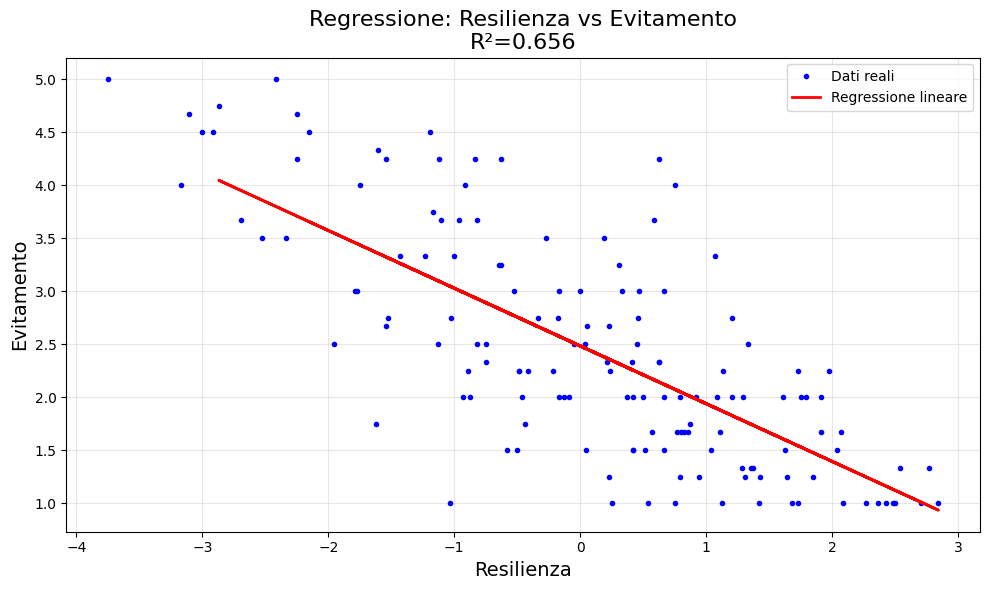

Coefficiente: -0.5445
Intercetta: 2.4833


In [579]:
# Grafico
plt.figure(figsize=(10, 6))
plt.plot(X_1, y_1, "b.", label='Dati reali')
plt.plot(X_test_1[:,0], y_pred_1, "r-", linewidth=2, label='Regressione lineare')
plt.xlabel("Resilienza", fontsize=14)
plt.ylabel("Evitamento", fontsize=14)
plt.title(f'Regressione: Resilienza vs Evitamento\nR²={r2_1:.3f}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("regressione_resilienza_evitamento")
plt.show()

print(f"Coefficiente: {lin_reg.coef_[0]:.4f}")
print(f"Intercetta: {lin_reg.intercept_:.4f}")

### 2) Regressione: Ansia vs Evitamento

In [580]:
X_2 = df[['ansia']].values
y_2 = df['evitamento'].values

In [581]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

In [582]:
# Modello
lin_reg2 = LinearRegression()
lin_reg2.fit(X_train_2, y_train_2)
y_pred_2 = lin_reg2.predict(X_test_2)

In [583]:
mse_2 = mean_squared_error(y_test_2, y_pred_2)
r2_2 = r2_score(y_test_2, y_pred_2)
print("Mean Squared Error:", mse_2)
print("R-squared:", r2_2)

Mean Squared Error: 0.3679437702256811
R-squared: 0.7199173925515049


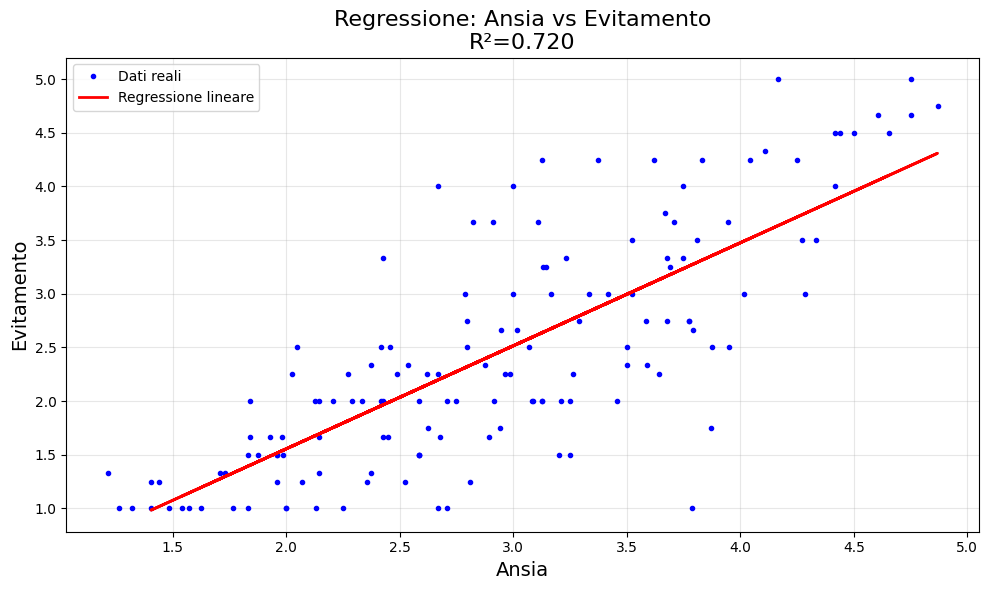

Coefficiente: 0.9599
Intercetta: -0.3648


In [584]:
# Grafico
plt.figure(figsize=(10, 6))
plt.plot(X_2, y_2, "b.", label='Dati reali')
plt.plot(X_test_2[:,0], y_pred_2, "r-", linewidth=2, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=14)
plt.ylabel("Evitamento", fontsize=14)
plt.title(f'Regressione: Ansia vs Evitamento\nR²={r2_2:.3f}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("regressione_ansia_evitamento")
plt.show()

print(f"Coefficiente: {lin_reg2.coef_[0]:.4f}")
print(f"Intercetta: {lin_reg2.intercept_:.4f}")

### 3) Regressione: Ansia vs Coping

In [585]:
X_3 = df[['ansia']].values
y_3 = df['coping'].values

In [586]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

In [587]:
# Modello
lin_reg3 = LinearRegression()
lin_reg3.fit(X_train_3, y_train_3)
y_pred_3 = lin_reg3.predict(X_test_3)

In [588]:
mse_3 = mean_squared_error(y_test_3, y_pred_3)
r2_3 = r2_score(y_test_3, y_pred_3)
print("Mean Squared Error:", mse_3)
print("R-squared:", r2_3)

Mean Squared Error: 0.3978641292011239
R-squared: 0.23671803214566256


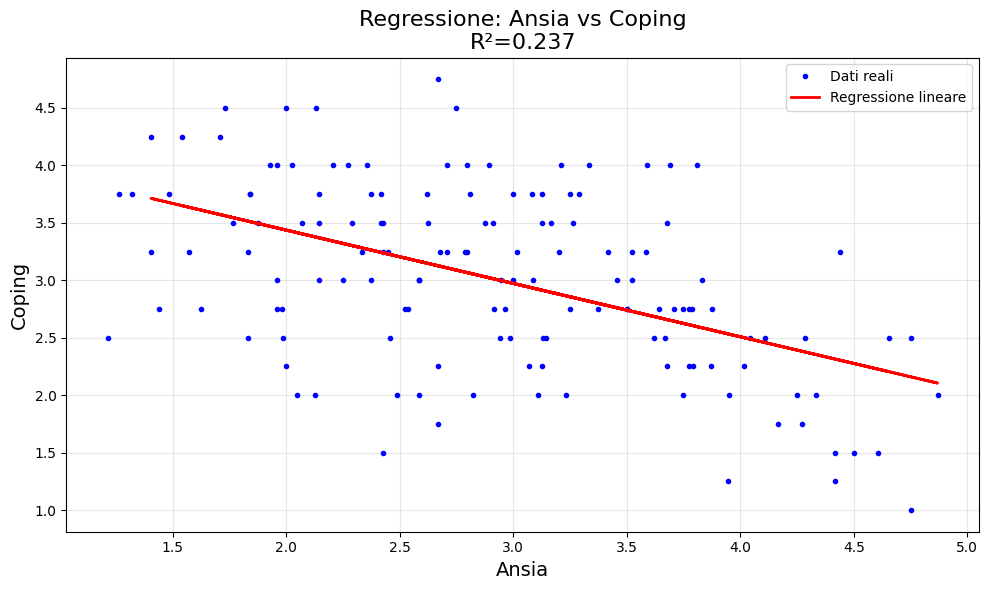

Coefficiente: -0.4640
Intercetta: 4.3644


In [589]:
# Grafico
plt.figure(figsize=(10, 6))
plt.plot(X_3, y_3, "b.", label='Dati reali')
plt.plot(X_test_3[:,0], y_pred_3, "r-", linewidth=2, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=14)
plt.ylabel("Coping", fontsize=14)
plt.title(f'Regressione: Ansia vs Coping\nR²={r2_3:.3f}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("regressione_lineare_ansia_coping")
plt.show()
 
print(f"Coefficiente: {lin_reg3.coef_[0]:.4f}")
print(f"Intercetta: {lin_reg3.intercept_:.4f}")

In [590]:
from sklearn.preprocessing import PolynomialFeatures

# trasformo X_test
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X_3.reshape(-1, 1))

In [591]:
model = LinearRegression()
model.fit(X_poly, y_3)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [592]:
y_pred_3_3 = model.predict(X_poly)
r2_3_3 = r2_score(y_3, y_pred_3_3)

In [593]:
mse_3_3 = mean_squared_error(y_3, y_pred_3_3)
r2_3_3 = r2_score(y_3, y_pred_3_3)
print("Mean Squared Error:", mse_3_3)
print("R-squared:", r2_3_3)

Mean Squared Error: 0.4465440231047396
R-squared: 0.28086503502367255


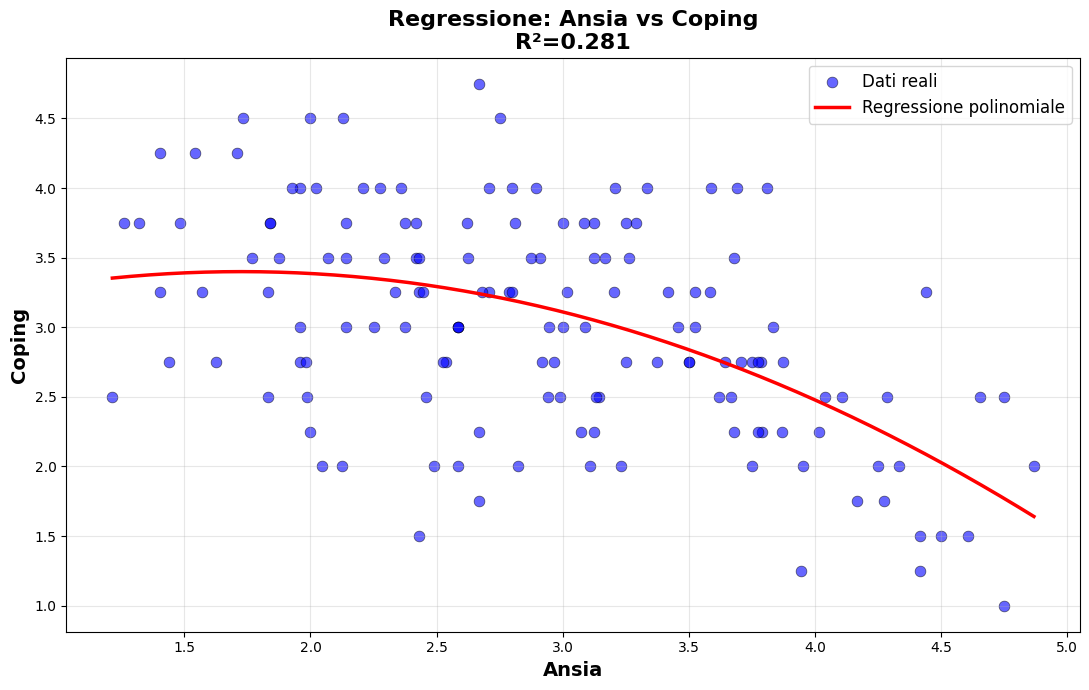

In [594]:
X_smooth = np.linspace(X_3.min(), X_3.max(), 300)
X_smooth_poly = poly_features.transform(X_smooth.reshape(-1, 1))
y_smooth = model.predict(X_smooth_poly)

# Grafico
fig, ax = plt.subplots(figsize=(11, 7))

# Scatter dei dati reali
ax.scatter(X_3, y_3, alpha=0.6, s=60, color='blue', 
          label='Dati reali', edgecolors='black', linewidth=0.5)

# Curva liscia di regressione
ax.plot(X_smooth, y_smooth, 'r-', linewidth=2.5, 
       label='Regressione polinomiale')

ax.set_xlabel("Ansia", fontsize=14, fontweight='bold')
ax.set_ylabel("Coping", fontsize=14, fontweight='bold')
ax.set_title(f'Regressione: Ansia vs Coping\nR²={r2_3_3:.3f}', 
            fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("regressione_poli2_ansia_evitamento")
plt.show()

In [595]:
poly_features = PolynomialFeatures(degree=3, include_bias=False)

# trasformo X_test
X_poly_3_2 = poly_features.fit_transform(X_3)

lin_reg3_3 = LinearRegression()

lin_reg3_3.fit(X_poly_3_2, y_3)

y_pred_3_3 = lin_reg3_3.predict(X_poly_3_2)

mse_3_3 = mean_squared_error(y_3, y_pred_3_3)
r2_3_3 = r2_score(y_3, y_pred_3_3)
print("Mean Squared Error:", mse_3_3)
print("R-squared:", r2_3_3)

Mean Squared Error: 0.4446572255947253
R-squared: 0.28390362022709226


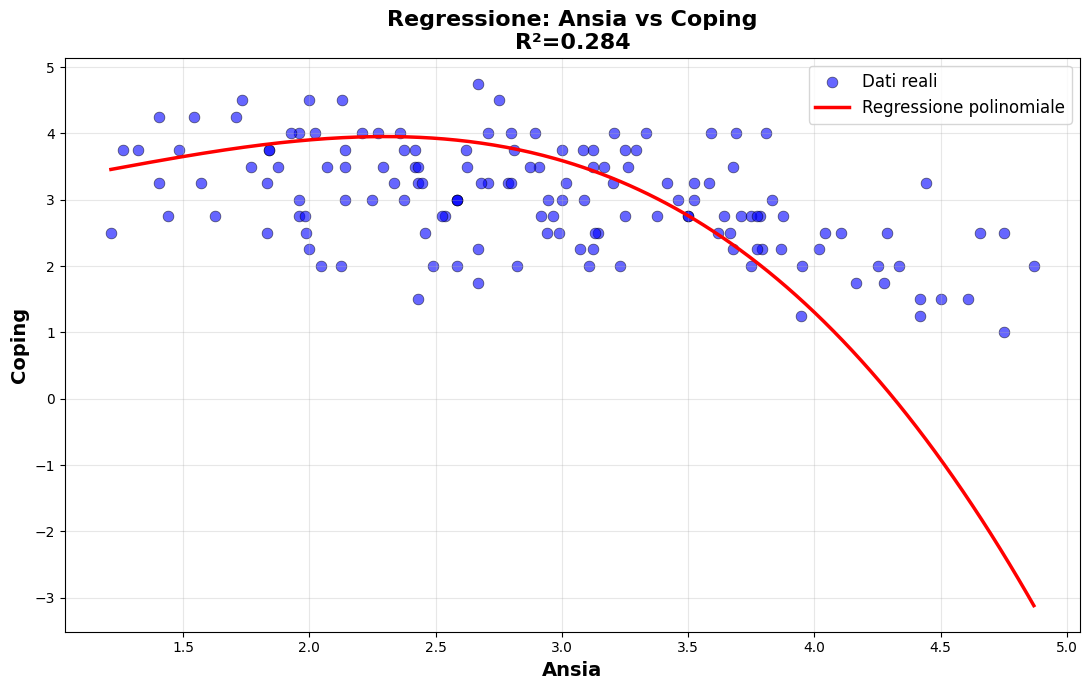

In [596]:
# X_smooth ordinato
X_smooth = np.linspace(X_3.min(), X_3.max(), 300)
X_smooth_poly = poly_features.transform(X_smooth.reshape(-1, 1))
y_smooth = model.predict(X_smooth_poly)

# Grafico
fig, ax = plt.subplots(figsize=(11, 7))

# Scatter dei dati reali
ax.scatter(X_3, y_3, alpha=0.6, s=60, color='blue', 
          label='Dati reali', edgecolors='black', linewidth=0.5)

# Curva liscia di regressione
ax.plot(X_smooth, y_smooth, 'r-', linewidth=2.5, 
       label='Regressione polinomiale')

ax.set_xlabel("Ansia", fontsize=14, fontweight='bold')
ax.set_ylabel("Coping", fontsize=14, fontweight='bold')
ax.set_title(f'Regressione: Ansia vs Coping\nR²={r2_3_3:.3f}', 
            fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("regressione_poli3_ansia_evitamento")
plt.show()

In [ ]:
# cross-validation
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# Modello di regressione lineare
lin_reg_cv = LinearRegression()
scores_lin = cross_val_score(lin_reg_cv, X_3, y_3, cv=5, scoring='r2')
print(f"R² medio (lineare): {scores_lin.mean():.3f}")

# Modello di regressione polinomiale di grado 2
poly_reg_cv_2 = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
scores_poly_2 = cross_val_score(poly_reg_cv_2, X_3, y_3, cv=5, scoring='r2')
print(f"R² medio (polinomiale grado 2): {scores_poly_2.mean():.3f}")

R² medio (lineare): 0.224
R² medio (polinomiale grado 2): 0.250


### 4) Regressione: Ansia vs Gap

In [598]:
df_reg4 = df.copy()

df_reg4 = df_reg4.dropna(subset=['ansia', 'gap'])

In [599]:
X_4 = df_reg4['ansia'].values
y_4 = df_reg4['gap'].values

In [600]:
X_4= X_4.reshape(-1, 1)
y_4 = y_4.reshape(-1, 1)

In [601]:
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_4, y_4, test_size=0.2, random_state=42)

In [602]:
# Modello
lin_reg4 = LinearRegression()
lin_reg4.fit(X_train_4, y_train_4)
y_pred_4 = lin_reg4.predict(X_test_4)

In [603]:
#valutazione
mse_4 = mean_squared_error(y_test_4, y_pred_4)
r2_4 = r2_score(y_test_4, y_pred_4)
print("Mean Squared Error:", mse_4)
print("R-squared:", r2_4)

Mean Squared Error: 1.0284097822014373
R-squared: 0.27051755248800535


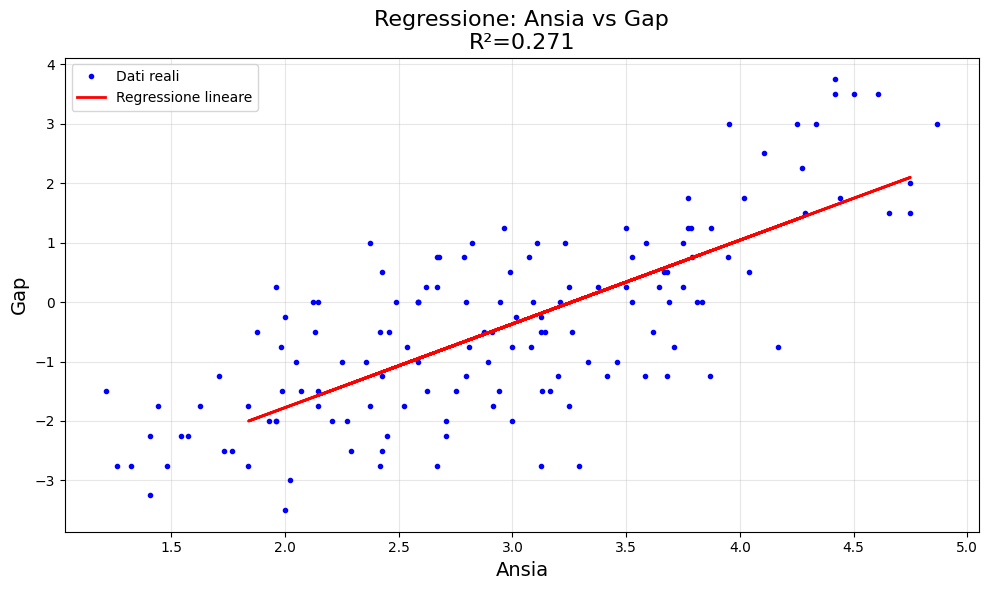

In [604]:
# Grafico
plt.figure(figsize=(10, 6))
plt.plot(X_4, y_4, "b.", label='Dati reali')
plt.plot(X_test_4[:,0], y_pred_4, "r-", linewidth=2, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=14)
plt.ylabel("Gap", fontsize=14)
plt.title(f'Regressione: Ansia vs Gap\nR²={r2_4:.3f}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("regressione_ansia_gap")
plt.show()

In [605]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)

# trasformo X_test
X_poly_4 = poly_features.fit_transform(X_4)

lin_reg4_2 = LinearRegression()

lin_reg4_2.fit(X_poly_4, y_4)

y_pred_4_2 = lin_reg4_2.predict(X_poly_4)

mse_4_2 = mean_squared_error(y_4, y_pred_4_2)
r2_4_2 = r2_score(y_4, y_pred_4_2)
print("Mean Squared Error:", mse_4_2)
print("R-squared:", r2_4_2)

Mean Squared Error: 1.0793890653491234
R-squared: 0.571778958284949


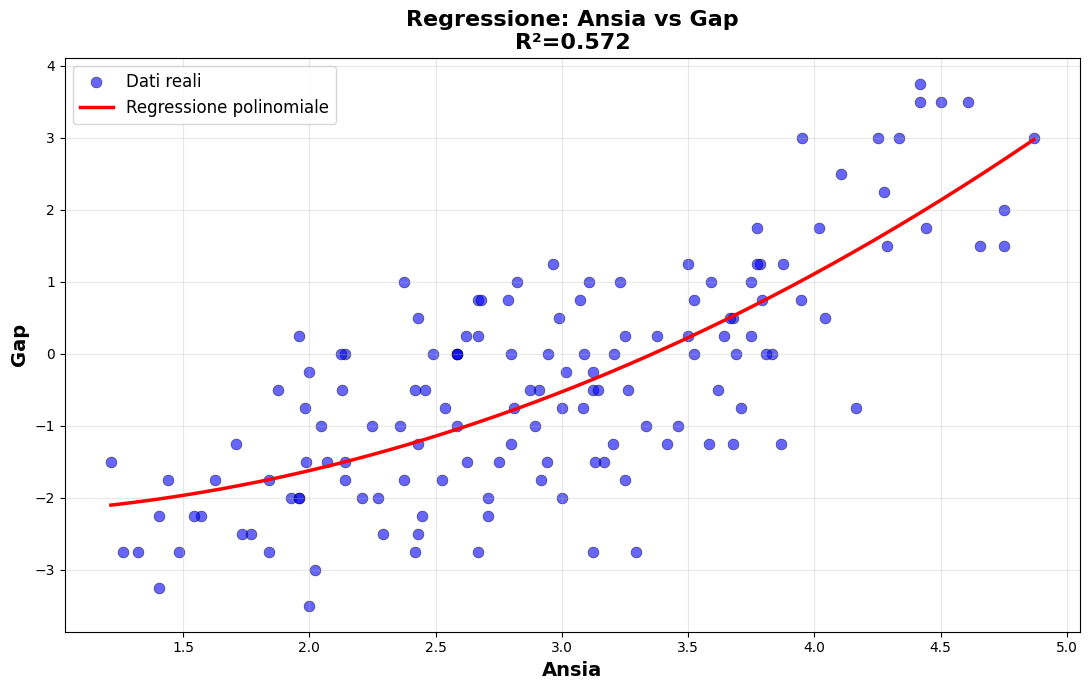

In [606]:
# X_smooth ordinato
X_smooth = np.linspace(X_4.min(), X_4.max(), 300)
X_smooth_poly = poly_features.transform(X_smooth.reshape(-1, 1))
y_smooth = lin_reg4_2.predict(X_smooth_poly)

# Grafico
fig, ax = plt.subplots(figsize=(11, 7))

# Scatter dei dati reali
ax.scatter(X_4, y_4, alpha=0.6, s=60, color='blue', 
          label='Dati reali', edgecolors='black', linewidth=0.5)

# Curva liscia di regressione
ax.plot(X_smooth, y_smooth, 'r-', linewidth=2.5, 
       label='Regressione polinomiale')

ax.set_xlabel("Ansia", fontsize=14, fontweight='bold')
ax.set_ylabel("Gap", fontsize=14, fontweight='bold')
ax.set_title(f'Regressione: Ansia vs Gap\nR²={r2_4_2:.3f}', 
            fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("regressione_poli4_ansia_gap")
plt.show()

In [ ]:
# cross-validation

# Modello di regressione lineare
lin_reg_cv = LinearRegression()
scores_lin = cross_val_score(lin_reg_cv, X_4, y_4, cv=3, scoring='r2')
print(f"R² medio (lineare): {scores_lin.mean():.3f}")

# Modello di regressione polinomiale di grado 2
poly_reg_cv = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
scores_poly2 = cross_val_score(poly_reg_cv, X_4, y_4, cv=3, scoring='r2')
print(f"R² medio (polinomiale grado 2): {scores_poly2.mean():.3f}")

# Modello di regressione polinomiale di grado 3 
poly3_reg_cv = make_pipeline(PolynomialFeatures(degree=3, include_bias=False), LinearRegression())
scores_poly3 = cross_val_score(poly3_reg_cv, X_4, y_4, cv=3, scoring='r2')
print(f"R² medio (polinomiale grado 3): {scores_poly3.mean():.3f}")

R² medio (lineare): 0.502
R² medio (polinomiale grado 2): 0.520
R² medio (polinomiale grado 3): 0.524


In [608]:
# split stratificato
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in kf.split(X_4):  # ← NO Y!
    X_train, X_test = X_4[train_idx], X_4[test_idx]
    y_train, y_test = y_4[train_idx], y_4[test_idx]

# Modello di regressione lineare
lin_reg_kf = LinearRegression()
lin_reg_kf.fit(X_train, y_train)
y_pred_kf = lin_reg_kf.predict(X_test)
mse_kf = mean_squared_error(y_test, y_pred_kf)
r2_kf = r2_score(y_test, y_pred_kf)
print(f"Fold MSE: {mse_kf:.3f}, R²: {r2_kf:.3f}")

# Modello di regressione polinomiale di grado 2
poly_reg_kf = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly_reg_kf.fit(X_train, y_train)
y_pred_poly_kf = poly_reg_kf.predict(X_test)
mse_poly_kf = mean_squared_error(y_test, y_pred_poly_kf)
r2_poly_kf = r2_score(y_test, y_pred_poly_kf)
print(f"Fold MSE (polinomiale grado 2): {mse_poly_kf:.3f}, R²: {r2_poly_kf:.3f}")


Fold MSE: 1.168, R²: 0.387
Fold MSE (polinomiale grado 2): 1.100, R²: 0.423
